# CNN architecture optimization: PyTorch & Optuna

**Optuna Dashboard:** To monitor optimization progress in real-time, start the Optuna dashboard in a terminal:

```text
optuna-dashboard sqlite:///data/pytorch/cnn_optimization.db
```

Then open http://localhost:8080 in your browser.

## 1. Notebook setup

### 1.1. Imports

In [22]:
# Standard library imports
import pickle

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets

# Package imports
from image_classification_tools.pytorch import DataPipeline
import image_classification_tools.pytorch.evaluation as eval_utils
import image_classification_tools.pytorch.hyperparameter_optimization as optimization
import image_classification_tools.pytorch.plotting as plots
import image_classification_tools.pytorch.training as training

# Local imports
import configuration as config
import helper_functions as hf

### 1.2. Run configuration

In [23]:
# Model control
rerun_optuna_study = False   # Set to False to load existing Optuna study from disk
retrain_model = False        # Set to False to load existing final model
model_source = 'huggingface' # 'local' or 'huggingface'

# Optuna study configuration
study_name = 'architecture_optimization'
study_storage = 'sqlite:///../data/pytorch/cnn_optimization.db'

# Parallel GPU configuration
n_parallel_workers = torch.cuda.device_count() if torch.cuda.is_available() else 1

### 1.3. Fixed hyperparameters

In [24]:
# Data loading
preload_device = 'gpu' if torch.cuda.is_available() else 'cpu'

# Optuna optimization settings
n_trials = 200
epochs_per_trial = 500
pruner_warmup_steps = 10
trial_early_stopping_patience = 10

# Final model training settings
learning_rate = 0.001
epochs = 500
early_stopping_patience = 15
print_every = 10

## 2. Plot sample images

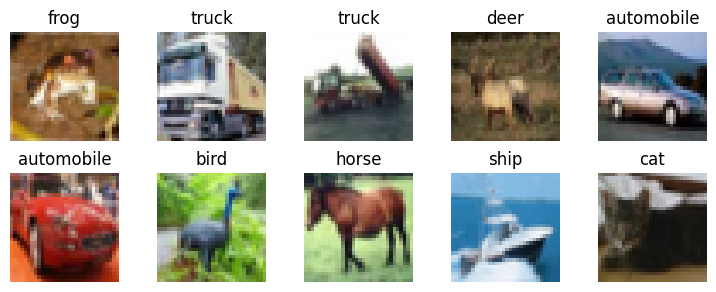

In [25]:
# Get a sample dataset for visualization
sample_dataset = datasets.CIFAR10(
    root=config.DATA_DIR,
    train=True,
    transform=config.RGB_TRANSFORM
)

# Plot first 10 images from the training dataset
fig, axes = plots.plot_sample_images(sample_dataset, config.CLASS_NAMES)
plt.show()

## 3. Optuna hyperparameter optimization

In [26]:
# Define model path
model_path = config.MODELS_DIR / 'architecture_optimized_cnn.pth'

# Load existing model if requested
if not retrain_model:

    model = hf.load_model_from_source(
        model_path=model_path,
        model_name='architecture_optimized_cnn.pth',
        model_source=model_source,
        device=config.DEVICE
    )
    
    # Try to load training history
    history = hf.load_history_from_source(
        model_path=model_path,
        model_name='architecture_optimized_cnn.pth',
        model_source=model_source
    )
    
    if model is None:
        print('Pretrained model not available, proceeding with training...')
        retrain_model = True

else:
    print('Training new model...')
    history = None

Model downloaded from Hugging Face
Training history downloaded from Hugging Face


### 3.1. Define hyperparameter search space

In [27]:
# Define hyperparameter search space
search_space = {
    'batch_size': [64, 128, 256],              # Smaller batches often generalize better
    'n_conv_blocks': (3, 12),                  # Deeper networks (max 12 for stability)
    'initial_filters': [32, 64],               # ResNet-18 to ResNet-50 range
    'filter_double_frequency': [2, 3, 4],      # Double filters every N blocks (3-4 = ResNet-like)
    'pool_frequency': [2, 3, 4],               # Pool every N blocks (enables deeper networks)
    'n_fc_layers': (1, 3),                     # Fewer FC layers (less overfitting)
    'conv_dropout_rate': (0.0, 0.4),           # Allow no dropout (BatchNorm may suffice)
    'fc_dropout_rate': (0.2, 0.6),             # FC layer dropout
    'learning_rate': (1e-4, 5e-2, 'log'),      # Wider range, higher max
}

print('Hyperparameter search space:\n')

for key, value in search_space.items():
    print(f'  {key}: {value}')

Hyperparameter search space:

  batch_size: [64, 128, 256]
  n_conv_blocks: (3, 12)
  initial_filters: [32, 64]
  filter_double_frequency: [2, 3, 4]
  pool_frequency: [2, 3, 4]
  n_fc_layers: (1, 3)
  conv_dropout_rate: (0.0, 0.4)
  fc_dropout_rate: (0.2, 0.6)
  learning_rate: (0.0001, 0.05, 'log')


### 3.2. Create CNN model factory for Optuna

In [28]:
def create_cnn(trial, num_classes, in_channels):
    '''Create a CNN with hyperparameters sampled from the trial.
    
    This function builds a flexible CNN architecture with conv blocks that
    progressively doubles the number of filters at a configurable frequency.
    Each conv block contains: 2 Conv layers + BatchNorm + ReLU + Conditional MaxPool + Dropout.
    MaxPooling frequency is configurable to support deeper architectures without
    spatial dimension collapse. For 32x32 inputs:
      - pool_frequency=2: up to 10 blocks (5 pools)
      - pool_frequency=3: up to 15 blocks (5 pools)
      - pool_frequency=4: up to 20 blocks (5 pools)
    Uses adaptive pooling before classifier to handle variable spatial dimensions.
    
    Args:
        trial: Optuna trial object for suggesting hyperparameters
        num_classes: Number of output classes
        in_channels: Number of input channels (3 for RGB, 1 for grayscale)
    
    Returns:
        nn.Sequential model
    '''
    
    # Sample architecture hyperparameters from the search space
    n_conv_blocks = trial.suggest_int('n_conv_blocks', *search_space['n_conv_blocks'])
    initial_filters = trial.suggest_categorical('initial_filters', search_space['initial_filters'])
    n_fc_layers = trial.suggest_int('n_fc_layers', *search_space['n_fc_layers'])
    conv_dropout_rate = trial.suggest_float('conv_dropout_rate', *search_space['conv_dropout_rate'])
    fc_dropout_rate = trial.suggest_float('fc_dropout_rate', *search_space['fc_dropout_rate'])
    
    # Pool frequency (optional, defaults to 2)
    if 'pool_frequency' in search_space:
        pool_frequency = trial.suggest_categorical('pool_frequency', search_space['pool_frequency'])

    else:
        pool_frequency = 2
    
    # Filter double frequency (optional, defaults to 2)
    if 'filter_double_frequency' in search_space:
        filter_double_frequency = trial.suggest_categorical(
            'filter_double_frequency', search_space['filter_double_frequency']
        )

    else:
        filter_double_frequency = 2

    layers = []
    current_channels = in_channels
    spatial_size = 32  # CIFAR-10 input size
    
    # Convolutional blocks
    for block_idx in range(n_conv_blocks):

        # Double filters every N blocks (configurable growth rate)
        out_channels = initial_filters * (2 ** (block_idx // filter_double_frequency))
        
        # First conv in block
        layers.append(nn.Conv2d(current_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Second conv in block
        layers.append(nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1))
        layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.ReLU())
        
        # Pool every N blocks, but only if spatial size allows (min 1x1 before adaptive pool)
        should_pool = (block_idx + 1) % pool_frequency == 0

        if should_pool and spatial_size > 1:
            layers.append(nn.MaxPool2d(2, 2))
            spatial_size //= 2
        
        layers.append(nn.Dropout(conv_dropout_rate))
        
        current_channels = out_channels
    
    # Classifier with adaptive pooling
    layers.append(nn.AdaptiveAvgPool2d((1, 1)))
    layers.append(nn.Flatten())
    
    # Generate FC layer sizes by halving from current_channels
    fc_sizes = []
    current_fc_size = current_channels // 2

    for _ in range(n_fc_layers):
        fc_sizes.append(max(32, current_fc_size))  # Minimum 32 units
        current_fc_size //= 2
    
    # Add FC layers
    in_features = current_channels

    for fc_size in fc_sizes:
        layers.append(nn.Linear(in_features, fc_size))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(fc_dropout_rate))
        in_features = fc_size
    
    # Output layer
    layers.append(nn.Linear(in_features, num_classes))
    
    return nn.Sequential(*layers)

### 3.3. Run Optuna optimization study

In [29]:
%%time

if rerun_optuna_study:
    
    # Display parallel worker configuration
    print(f'Running optimization with {n_parallel_workers} parallel workers')

    if torch.cuda.is_available():
        print(f'Available GPUs: {torch.cuda.device_count()}')

        for i in range(torch.cuda.device_count()):
            print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')
    
    # Create objective function
    objective = optimization.create_objective(
        model_factory=create_cnn,
        data_source=datasets.CIFAR10,
        data_dir=config.DATA_DIR,
        train_transform=config.RGB_TRANSFORM,
        eval_transform=config.RGB_TRANSFORM,
        n_epochs=epochs_per_trial,
        num_classes=len(config.CLASS_NAMES),
        in_channels=3,
        val_size=config.VAL_SIZE,
        search_space=search_space,
        early_stopping_patience=trial_early_stopping_patience
    )
    
    # Create Optuna study with pruning and database storage
    study = optuna.create_study(
        direction='maximize',
        study_name=study_name,
        storage=study_storage,
        load_if_exists=True,
        pruner=optuna.pruners.MedianPruner(
            n_warmup_steps=pruner_warmup_steps
        )
    )
    
    # Run optimization
    study.optimize(
        objective, 
        n_trials=n_trials, 
        n_jobs=n_parallel_workers,
        catch=(optimization.TrialFailedError,)
    )
    
    print(f'\nBest trial: {study.best_trial.number}')
    print(f'Best validation accuracy: {study.best_value:.2f}%')

else:

    # Load existing study
    study = optuna.load_study(
        study_name=study_name,
        storage=study_storage
    )
    print(f'Study loaded from: {study_storage}')
    print(f'Best validation accuracy: {study.best_value:.2f}%')

print()

Study loaded from: sqlite:///../data/pytorch/cnn_optimization.db
Best validation accuracy: 88.79%

CPU times: user 57.8 ms, sys: 1.95 ms, total: 59.8 ms
Wall time: 58.4 ms


### 3.4. Visualize optimization results

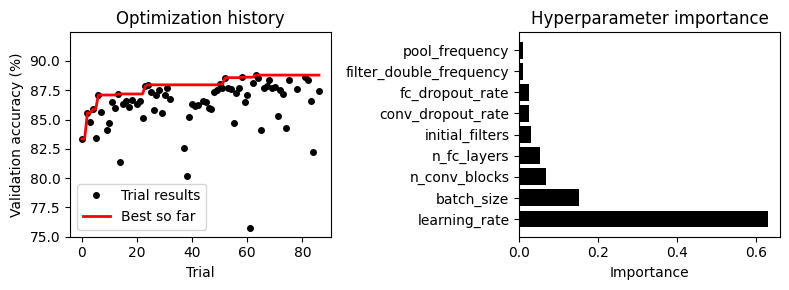

In [43]:
fig, axes = plots.plot_optimization_results(
    study,
    ylim=(75, None)
)

plt.show()

## 4. Train final model with best hyperparameters

### 4.1. Load winning hyperparameters

In [31]:
# Extract best hyperparameters
best_params = study.best_trial.params

print('Best hyperparameters:\n')

for key, value in best_params.items():
    print(f'  {key}: {value}')

Best hyperparameters:

  batch_size: 256
  n_conv_blocks: 7
  initial_filters: 64
  n_fc_layers: 1
  conv_dropout_rate: 0.3970168590808983
  fc_dropout_rate: 0.41794948916615016
  pool_frequency: 4
  filter_double_frequency: 3
  learning_rate: 0.0003262697843356068


### 4.2. Re-create dataloader with winning batch size

In [32]:
# Recreate data loaders with best batch size
from image_classification_tools.pytorch import DataPipeline

best_batch_size = best_params['batch_size']

loaders = DataPipeline(
    data_source=datasets.CIFAR10,
    split='train/val/test',
    train_transform=config.RGB_TRANSFORM,
    eval_transform=config.RGB_TRANSFORM,
    preload=preload_device,
    batch_size=best_batch_size,
    val_size=config.VAL_SIZE,
    seed=config.SEED,
    root=config.DATA_DIR
).get_loaders()

train_loader = loaders.train
val_loader = loaders.val
test_loader = loaders.test

Loading train dataset...


Loading test dataset...
Creating splits...
Preloading train to GPU:0...


Preloading train: 100%|██████████| 40000/40000 [00:15<00:00, 2502.12it/s]


Preloading val to GPU:0...


Preloading val: 100%|██████████| 10000/10000 [00:03<00:00, 2655.67it/s]


### 4.3. Create optimized model

In [33]:
if retrain_model:

    # Create model with best hyperparameters using the same factory function
    mock_trial = optimization.MockTrial(best_params)

    best_model = create_cnn(
        trial=mock_trial,
        num_classes=len(config.CLASS_NAMES),
        in_channels=3
    ).to(config.DEVICE)

    # Create optimizer with best learning rate (fixed Adam optimizer)
    best_optimizer = optim.Adam(
        best_model.parameters(), 
        lr=best_params['learning_rate']
    )

    # Set cross-entropy loss
    criterion = torch.nn.CrossEntropyLoss()

    # Get total trainable parameters
    trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

    print(f'\n{best_model}')
    print(f'\nTotal parameters: {trainable_params:,}')

else:
    # Use the loaded model
    best_model = model
    print('Using loaded model')
    print(f'\nTotal parameters: {sum(p.numel() for p in best_model.parameters()):,}')

Using loaded model

Total parameters: 1,920,970


### 4.4. Train optimized model

In [34]:
%%time

if retrain_model:
    history = training.train_model(
        model=best_model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=best_optimizer,
        device=config.DEVICE,
        epochs=epochs,
        print_every=print_every,
        enable_early_stopping=True,
        early_stopping_patience=early_stopping_patience
    )

    print()
else:
    print('Training skipped - using loaded model\n')

Training skipped - using loaded model

CPU times: user 63 µs, sys: 5 µs, total: 68 µs
Wall time: 68.7 µs


### 4.5. Learning curves

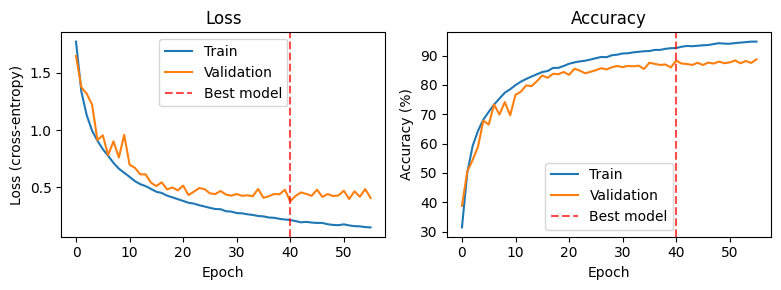

In [35]:
fig, axes = plots.plot_learning_curves(history)
plt.show()

## 5. Evaluate optimized model on test set

### 5.1. Calculate test accuracy

In [36]:
test_accuracy, predictions, true_labels = eval_utils.evaluate_model(
    best_model,
    test_loader
)

print(f'Test accuracy: {test_accuracy:.2f}%')

Test accuracy: 88.11%


### 5.2. Per-class accuracy

In [37]:
# Calculate per-class accuracy
class_correct = {name: 0 for name in config.CLASS_NAMES}
class_total = {name: 0 for name in config.CLASS_NAMES}

for pred, true in zip(predictions, true_labels):

    class_name = config.CLASS_NAMES[true]
    class_total[class_name] += 1

    if pred == true:
        class_correct[class_name] += 1

print('Per-class accuracy:')
print('-' * 30)

for name in config.CLASS_NAMES:
    acc = 100 * class_correct[name] / class_total[name]
    print(f'{name:12s}: {acc:.2f}%')

Per-class accuracy:
------------------------------
airplane    : 88.60%
automobile  : 93.10%
bird        : 84.00%
cat         : 78.60%
deer        : 91.80%
dog         : 76.80%
frog        : 89.60%
horse       : 91.90%
ship        : 92.80%
truck       : 93.90%


### 5.3. Confusion matrix

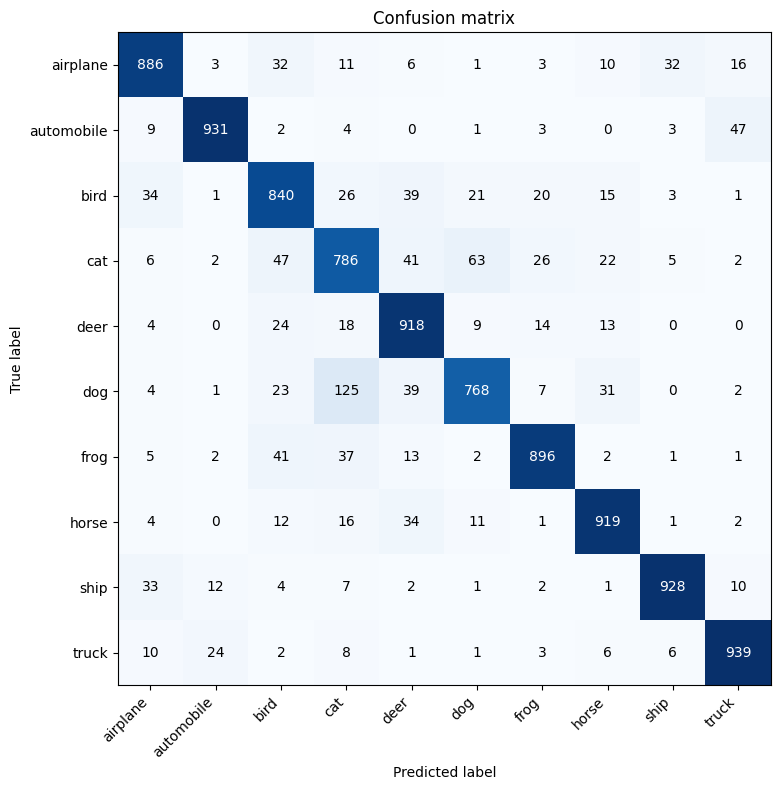

In [38]:
fig, ax = plots.plot_confusion_matrix(true_labels, predictions, config.CLASS_NAMES)
plt.show()

### 5.4. Predicted class probability distributions

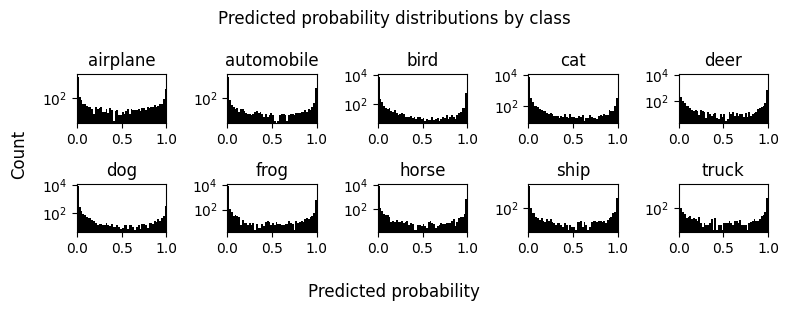

In [39]:
# Get predicted probabilities for all test samples
best_model.eval()
all_probs = []

with torch.no_grad():
    for images, _ in test_loader:
        outputs = best_model(images.to(config.DEVICE))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())

all_probs = np.concatenate(all_probs, axis=0)

# Plot probability distributions
fig, axes = plots.plot_class_probability_distributions(all_probs, config.CLASS_NAMES)
plt.show()

### 5.5. Evaluation curves

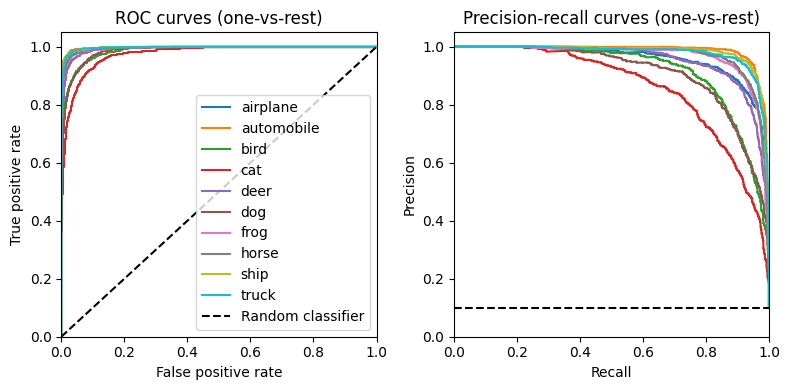

In [40]:
fig, (ax1, ax2) = plots.plot_evaluation_curves(true_labels, all_probs, config.CLASS_NAMES)
plt.show()

## 6. Save optimized model and hyperparameters

In [41]:
if retrain_model:

    # Save trained model (and auto-upload to Hugging Face if configured)
    # Extract database path from study_storage URI
    study_db_path = config.DATA_DIR / 'pytorch' / 'cnn_optimization.db'
    
    hf.save_and_upload_model(
        model=best_model,
        model_path=model_path,
        model_name='architecture_optimized_cnn.pth',
        history=history,
        optuna_study_path=study_db_path,
        optuna_study_name='cnn_optimization.db'
    )

## 7. Save test results for comparison

In [42]:
# Save performance results
results_path = config.RESULTS_DIR / 'architecture_optimized_cnn_results.pkl'

# Count model parameters
total_params = sum(p.numel() for p in best_model.parameters())
trainable_params = sum(p.numel() for p in best_model.parameters() if p.requires_grad)

# Create results dictionary
results_dict = {
    'true_labels': true_labels,
    'predictions': predictions,
    'all_probs': all_probs,
    'test_accuracy': test_accuracy,
    'total_params': total_params,
    'trainable_params': trainable_params
}

# Save results
with open(results_path, 'wb') as f:
    pickle.dump(results_dict, f)

print(f'Test results saved to: {results_path}')
print(f'  - Test accuracy: {test_accuracy:.2f}%')
print(f'  - Total parameters: {total_params:,}')
print(f'  - Trainable parameters: {trainable_params:,}')

Test results saved to: ../data/pytorch/performance_results/architecture_optimized_cnn_results.pkl
  - Test accuracy: 88.11%
  - Total parameters: 1,920,970
  - Trainable parameters: 1,920,970
